In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# ResNet50
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [23]:
# @title 1. Setup: Install Libraries
# This cell installs all necessary packages.
!pip install gdown tensorflow scikit-learn seaborn matplotlib numpy Pillow albumentations -q
print("Libraries are ready.")


Libraries are ready.


In [24]:
# @title 2. Setup: Define Paths
# Upload to access datasets and save model files.
import os
print("Setting up directories...")
# --- Main Path Configuration ---
KAGGLE_BASE_PATH = '/kaggle/input/braintumordetection/Datasets/'

# Define all paths based on the base path
TRAINING_DIR = os.path.join(KAGGLE_BASE_PATH, 'Training')
# ADDED: Path for the new validation dataset
VALIDATION_DIR = os.path.join(KAGGLE_BASE_PATH, 'Validation')
# RENAMED: This is now for the final test set
TESTING_DIR = os.path.join(KAGGLE_BASE_PATH, 'Testing')
CHECKPOINT_DIR = '/kaggle/working/Checkpoints'
LOG_DIR = '/kaggle/working/Logs'

# Create directories if they don't exist
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Verify that the core directories exist
assert os.path.exists(TRAINING_DIR), f"Training directory not found at: {TRAINING_DIR}"
assert os.path.exists(VALIDATION_DIR), f"Validation directory not found at: {VALIDATION_DIR}"
assert os.path.exists(TESTING_DIR), f"Testing directory not found at: {TESTING_DIR}"

print(f"Setup complete. Checkpoints will be saved to: {CHECKPOINT_DIR}")


Setting up directories...
Setup complete. Checkpoints will be saved to: /kaggle/working/Checkpoints


In [25]:
# @title 3. Configuration: Set Hyperparameters
# Centralize all key model and training parameters here.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50 # EarlyStopping will find the optimal number
LEARNING_RATE = 0.00005
print("Hyperparameters configured.")


Hyperparameters configured.


In [26]:
# @title 4. Data Preparation: Augmentation and Generators
# Create data generators that will feed images to the model.
import tensorflow as tf
import albumentations as A
import numpy as np

# Define the Augmentation Pipeline using Albumentations
augmentor = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=40, p=0.7),
    A.ElasticTransform(p=0.4, alpha=120, sigma=120 * 0.05),
    A.GridDistortion(p=0.4),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
])

# Define a pure Python function for augmentation
def aug_fn(image):
    # Convert the TensorFlow tensor to a NumPy array
    image_np = image.numpy()  # This will work only in eager mode
    augmented_image = augmentor(image=image_np)['image']  # Apply augmentation
    return augmented_image

# Define a TensorFlow wrapper that uses tf.py_function
def process_data(image, label):
    # Use tf.py_function to call the augmentation function
    aug_img = tf.py_function(func=aug_fn, inp=[image], Tout=tf.float32)
    aug_img.set_shape([*IMG_SIZE, 3])  # Set the shape of the augmented image
    label.set_shape([])  # Set the shape of the label
    return aug_img, label

# Create the TensorFlow Datasets
# Load training data individually to apply our mapping function
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAINING_DIR, labels='inferred', label_mode='int', image_size=IMG_SIZE,
    interpolation='nearest', batch_size=None, shuffle=True
)

# Load validation and test data in batches
val_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR, labels='inferred', label_mode='int', image_size=IMG_SIZE,
    interpolation='nearest', batch_size=BATCH_SIZE, shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TESTING_DIR, labels='inferred', label_mode='int', image_size=IMG_SIZE,
    interpolation='nearest', batch_size=BATCH_SIZE, shuffle=False
)

# Get class info
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes found: {CLASS_NAMES}")

# Build the data pipelines
rescale_layer = tf.keras.layers.Rescaling(1./255)

# Create the base training generator (un-batched)
train_generator = train_ds.map(lambda x, y: (rescale_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
train_generator = train_generator.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)

# Create final validation and test generators
validation_generator = val_ds.map(lambda x, y: (rescale_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_generator = test_ds.map(lambda x, y: (rescale_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

print("Data pipelines created successfully.")


Found 4917 files belonging to 4 classes.
Found 1053 files belonging to 4 classes.
Found 1053 files belonging to 4 classes.
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Data pipelines created successfully.


In [27]:
# @title 5. Calculate and Apply Class Weights for Imbalance
# This addresses dataset imbalance by creating sample weights for the tf.data pipeline.
from sklearn.utils import class_weight

print("[INFO] Extracting labels to calculate class weights...")

# Create a NumPy array directly from the list of scalar labels
train_labels = np.array([y for x, y in train_ds])
class_labels_int = train_labels.astype(np.int64)

# Calculate class weights
class_weights_val = class_weight.compute_class_weight(
    'balanced', classes=np.unique(class_labels_int), y=class_labels_int
)
class_weights_dict = dict(enumerate(class_weights_val))
print(f"\nCalculated Weights: {class_weights_dict}")

# Create a TensorFlow lookup table
keys_tensor = tf.constant(list(class_weights_dict.keys()), dtype=tf.int64)
vals_tensor = tf.constant(list(class_weights_dict.values()), dtype=tf.float32)
weight_lookup_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys_tensor, vals_tensor),
    default_value=tf.constant(1.0, dtype=tf.float32)
)

# Define the function that applies weights
def apply_sample_weights(image, label):
    label_int = tf.cast(label, tf.int64)
    sample_weight = weight_lookup_table.lookup(label_int)
    return image, label, sample_weight
    

[INFO] Extracting labels to calculate class weights...

Calculated Weights: {0: 1.0830396475770925, 1: 1.0679843614248479, 2: 0.8780357142857143, 3: 0.9985783915515841}


In [28]:
# @title 6. Model Architecture: Build ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2

# Using MirroredStrategy for efficient training on multiple GPUs if available
try:
    strategy = tf.distribute.MirroredStrategy()
    print('Number of devices: {}'.format(strategy.num_replicas_in_sync))
except:
    print("MirroredStrategy not available. Running on single device.")
    strategy = tf.distribute.get_strategy()

with strategy.scope():
    def build_model(num_classes):
        base_model = ResNet50(
            weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3), pooling='avg'
        )
        base_model.trainable = False

        model = models.Sequential([
            base_model,
            layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation='softmax')
        ])
        return model

    model = build_model(NUM_CLASSES)

print("\nModel built successfully. Summary:")
model.summary()


Number of devices: 2

Model built successfully. Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,640,900 (94.00 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [29]:
# @title 7. Training: Configure Callbacks and Start Training 
# Callbacks are configured, including TensorBoard for monitoring.
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, TensorBoard
from datetime import datetime

# Create the final, batched, and weighted training dataset
print("[INFO] Assembling final training data pipeline...")
train_dataset_final = train_generator.map(
    apply_sample_weights, num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print("Final training dataset ready.")

# Configure Callbacks
def get_callbacks():
    return [
        ModelCheckpoint(filepath=os.path.join(CHECKPOINT_DIR, 'ResNet50_best_model.keras'),
                        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
        CSVLogger(os.path.join(CHECKPOINT_DIR, 'ResNet50_training_log.csv')),
        TensorBoard(log_dir=os.path.join(LOG_DIR, datetime.now().strftime("%Y%m%d-%H%M%S")), histogram_freq=1)
    ]

callbacks = get_callbacks()

# Using the strategy scope for model compilation and training
with strategy.scope():
    # Train the Classifier Head
    print("\n[INFO] STAGE 1: Training the classifier head...")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    try:
        history_head = model.fit(
            train_dataset_final, epochs=15, validation_data=validation_generator, callbacks=callbacks, verbose=1
        )
    except Exception as e:
        print(f"An error occurred during training: {e}")

    # Fine-Tune the Top Layers
    print("\n[INFO] STAGE 2: Unfreezing and fine-tuning top layers...")
    model.layers[0].trainable = True
    for layer in model.layers[0].layers[:-50]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE / 10),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    try:
        history_fine_tune = model.fit(
            train_dataset_final, epochs=EPOCHS, initial_epoch=history_head.epoch[-1] + 1,
            validation_data=validation_generator, callbacks=callbacks, verbose=1
        )
    except Exception as e:
        print(f"An error occurred during fine-tuning: {e}")

# Save the Final Model
final_model_path = os.path.join(CHECKPOINT_DIR, 'ResNet50_final_model.keras')
model.save(final_model_path)
print(f"\nTraining complete! Final model saved to: {final_model_path}")


[INFO] Assembling final training data pipeline...
Final training dataset ready.

[INFO] STAGE 1: Training the classifier head...
Epoch 1/15


I0000 00:00:1754035106.066503     121 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1754035106.067074     119 cuda_dnn.cc:529] Loaded cuDNN version 90300


154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: nan - loss: nan
Epoch 1: val_accuracy improved from -inf to 0.99464, saving model to /kaggle/working/Checkpoints/ResNet50_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 71s 342ms/step - accuracy: nan - loss: nan - val_accuracy: 0.9946 - val_loss: 1.6256 - learning_rate: 5.0000e-05
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: nan - loss: nan
Epoch 2: val_accuracy did not improve from 0.99464
154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 299ms/step - accuracy: nan - loss: nan - val_accuracy: 0.9746 - val_loss: 1.3433 - learning_rate: 5.0000e-05
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: nan - loss: nan
Epoch 3: val_accuracy did not improve from 0.99464
154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 299ms/step - accuracy: nan - loss: nan - val_accuracy: 0.0209 - val_loss: 1.7051 - learning_rate: 5.0000e-05
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: nan - loss: nan
Epoch 4: val_accuracy did not im

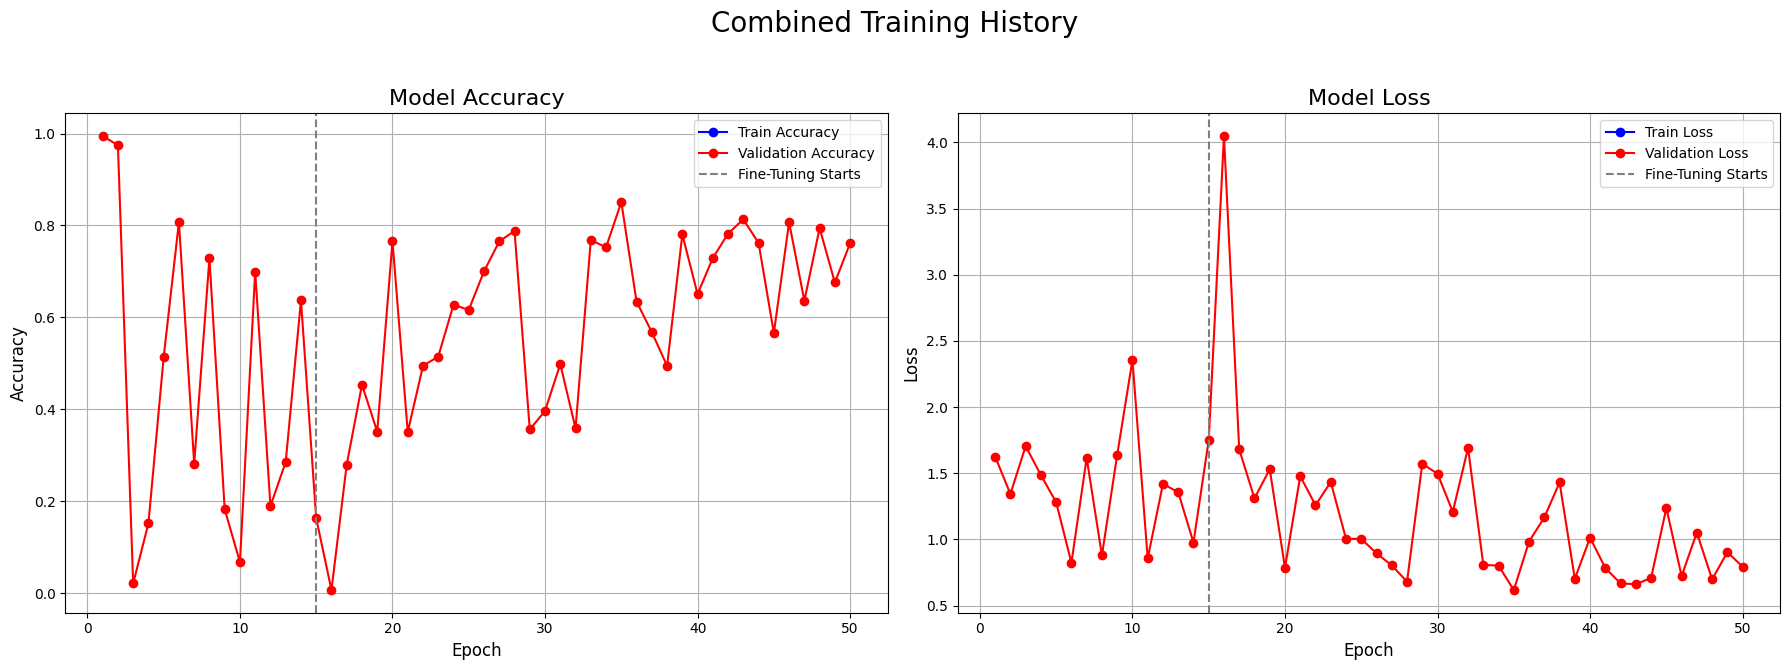

In [30]:
# @title 8. Evaluation: Visualize Training History
# Plotting accuracy and loss is essential for diagnosing model performance.
import matplotlib.pyplot as plt

def plot_full_history(history_head, history_fine_tune):
    """Plots combined accuracy and loss curves for both training stages."""
    # Combine history data
    history = {
        'accuracy': history_head.history['accuracy'] + history_fine_tune.history['accuracy'],
        'val_accuracy': history_head.history['val_accuracy'] + history_fine_tune.history['val_accuracy'],
        'loss': history_head.history['loss'] + history_fine_tune.history['loss'],
        'val_loss': history_head.history['val_loss'] + history_fine_tune.history['val_loss'],
    }
    
    epochs = range(1, len(history['accuracy']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot Accuracy
    ax1.plot(epochs, history['accuracy'], 'bo-', label='Train Accuracy')
    ax1.plot(epochs, history['val_accuracy'], 'ro-', label='Validation Accuracy')
    ax1.axvline(x=len(history_head.epoch), color='gray', linestyle='--', label='Fine-Tuning Starts')
    ax1.set_title('Model Accuracy', fontsize=16)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True)

    # Plot Loss
    ax2.plot(epochs, history['loss'], 'bo-', label='Train Loss')
    ax2.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    ax2.axvline(x=len(history_head.epoch), color='gray', linestyle='--', label='Fine-Tuning Starts')
    ax2.set_title('Model Loss', fontsize=16)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True)  
    plt.suptitle('Combined Training History', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_full_history(history_head, history_fine_tune)


[INFO] Evaluating the final model on the unseen test dataset...
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9327 - loss: 0.3889

--- Final Test Set Performance ---
Loss           : 0.3969
Compile_metrics: 0.9291
----------------------------------

[INFO] Generating classification report and confusion matrix...
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step

[CLASSIFICATION REPORT - TEST SET]

              precision    recall  f1-score   support

      glioma       0.64      0.86      0.73       243
  meningioma       0.77      0.34      0.47       247
     notumor       0.87      0.93      0.90       300
   pituitary       0.81      0.91      0.86       263

    accuracy                           0.77      1053
   macro avg       0.77      0.76      0.74      1053
weighted avg       0.78      0.77      0.75      1053


[CONFUSION MATRIX - TEST SET]



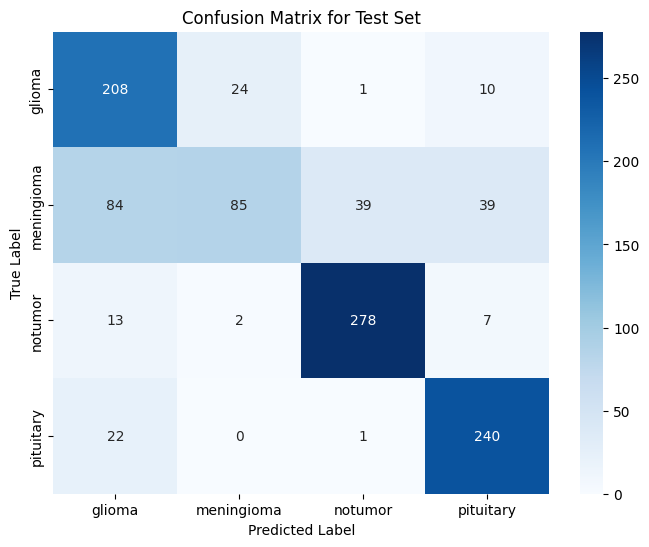

In [31]:
# @title 9. Final Evaluation on the Test Set
# Evaluate the final model on the unseen test set.
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("[INFO] Evaluating the final model on the unseen test dataset...")
results = model.evaluate(test_generator, verbose=1)
results_dict = dict(zip(model.metrics_names, results))

print("\n--- Final Test Set Performance ---")
for metric, value in results_dict.items():
    print(f"{metric.capitalize():<15}: {value:.4f}")
print("----------------------------------\n")

print("[INFO] Generating classification report and confusion matrix...")
# Extract true labels and predicted labels from the test_generator
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n[CLASSIFICATION REPORT - TEST SET]\n")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

print("\n[CONFUSION MATRIX - TEST SET]\n")
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()



Running prediction with the final model...

Processing image: Te-gl_0011.jpg


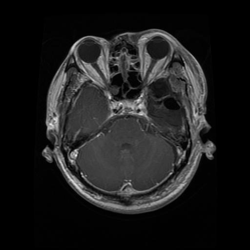

W0000 00:00:1754037681.319450      36 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Conv2D" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NCHW" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "VALID" } } attr { key: "strides" value { list { i: 1 i: 1 i: 2 i: 2 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 3 } dim { size: 230 } dim { size: 230 } } } inputs { dtype: DT_FLOAT shape { dim { size: 7 } dim { size: 7 } dim { size: 3 } dim { size: 64 } } } device { type: "GPU" vendor: "NVIDIA" model: "Tesla T4" frequency: 1590 num_cores: 40 environment { key: "architecture" value: "7.5" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90300" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 4194304 shared_memory_size_per_multi

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Prediction: **Glioma**
  Confidence: **92.30%**


In [33]:
# @title 10. Prediction: Test on Your Own Image
# Use the fully trained and improved model to make predictions on new images.
from tensorflow.keras.preprocessing import image
from PIL import Image as PilImage

def preprocess_image(img_path, img_size):
    """Loads and preprocesses an image from a file path for model prediction."""
    img = PilImage.open(img_path).convert('RGB')
    img = img.resize(img_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array /= 255.0 # Rescale (same as rescale_layer)
    return img_array

print("\nRunning prediction with the final model...")
# Example image path
image_path = "/kaggle/input/braintumordetection/Datasets/Testing/glioma/Te-gl_0011.jpg"

if not os.path.exists(image_path):
    print(f"Error: File not found at '{image_path}'")
else:
    print(f"\nProcessing image: {os.path.basename(image_path)}")
    from IPython.display import display
    display(PilImage.open(image_path).resize((250, 250)))

    # Preprocess the image and predict
    processed_image = preprocess_image(image_path, IMG_SIZE)
    predictions = model.predict(processed_image)

    # Get the results
    confidence = np.max(predictions[0])
    predicted_class_index = np.argmax(predictions[0])
    predicted_label = CLASS_NAMES[predicted_class_index]

    print(f"\nPrediction: **{predicted_label.replace('_', ' ').title()}**")
    print(f"  Confidence: **{confidence:.2%}**")
    